 # Sistema de Recomendação de Perfumes Nacionais
 **Projeto 1 · Introdução a Inteligência Artificial · UnB 2026/1**

 Sistema de recomendação para uma loja virtual de perfumes nacionais, combinando dois modelos:

 - **TF-IDF** - gera candidatos com base nas preferências declaradas pelo usuário no formulário (família olfativa, ocasião, faixa de preço)
 - **SVD** - reordena os candidatos usando a matriz de utilidade de 500 usuários, priorizando perfumes bem avaliados por usuários com perfil similar

 Essa abordagem híbrida resolve o problema de novos usuários sem histórico, onde eles vão receber recomendações pelo TF-IDF, que são então refinadas pelo SVD.

 ## Instalação das dependências

In [1]:
%pip install pandas scikit-learn scipy seaborn matplotlib gradio joblib

Note: you may need to restart the kernel to use updated packages.


 ## 1. Carregamento dos dados

In [ ]:
import pandas as pd

# carregando o csv
df_produtos = pd.read_csv("../dados/produtos.csv")
df_produtos.head()

,id,nome,marca,genero,familia_olfativa,notas_olfativas,ocasiao,preco,imagem_path
0,1,Malbec Tradicional,O Boticário,masculino,amadeirado aromatico,"bergamota, lavanda, cedro, vetiver, patchouli",noturno-formal,189.9,imagens/01_malbec_tradicional
1,2,Malbec Black,O Boticário,masculino,amadeirado especiado,"canela, pimenta rosa, cedro, couro, whisky",noturno-inverno,179.9,imagens/02_malbec_black
2,3,Lily Essence,O Boticário,feminino,floral,"lirio, rosa, iris, ambar, baunilha",noturno-formal,159.9,imagens/03_lily_essence
3,4,Lily Absolu,O Boticário,feminino,floral oriental,"lirio, jasmim, patchouli, baunilha, ambar",noturno-inverno,319.9,imagens/04_lily_absolu
4,5,Coffee Man Duo,O Boticário,masculino,amadeirado aromatico,"cafe, bergamota, gengibre, patchouli, sandalo",diurno-casual,149.9,imagens/05_coffee_man_duo


In [ ]:
df_matriz = pd.read_csv('../dados/matriz_utilidade.csv', index_col='usuario_id')
df_matriz.head()

,p1,p2,p3,p4,p5,p6,p7,p8,p9,p10,...,p41,p42,p43,p44,p45,p46,p47,p48,p49,p50
usuario_id,,,,,,,,,,,,,,,,,,,,,
u1,0,0,0,0,4,0,1,0,0,0,...,2,0,2,0,0,0,0,0,0,5
u2,0,3,0,0,4,0,0,0,0,0,...,4,0,0,3,0,0,0,0,0,0
u3,0,0,0,2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
u4,0,0,0,3,4,2,0,0,0,0,...,4,4,0,0,4,4,0,0,0,3
u5,0,3,0,0,0,0,0,0,0,0,...,0,0,0,3,0,0,1,0,0,0


 ## 2. Análise Exploratória dos Dados (EDA)

 ### 2.1 Visão geral dos datasets

In [ ]:
print(df_produtos.info())
print(f'\n#########')
print(df_produtos.describe())

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50 non-null     int64  
 1   nome              50 non-null     str    
 2   marca             50 non-null     str    
 3   genero            50 non-null     str    
 4   familia_olfativa  50 non-null     str    
 5   notas_olfativas   50 non-null     str    
 6   ocasiao           50 non-null     str    
 7   preco             50 non-null     float64
 8   imagem_path       50 non-null     str    
dtypes: float64(1), int64(1), str(7)
memory usage: 3.6 KB
None

#########
             id      preco
count  50.00000   50.00000
mean   25.50000  159.80200
std    14.57738   58.58894
min     1.00000   69.90000
25%    13.25000  132.40000
50%    25.50000  149.90000
75%    37.75000  179.90000
max    50.00000  319.90000


 O catálogo possui 50 perfumes com 9 colunas: id, nome, marca, gênero, família olfativa, notas olfativas, ocasião, preço e caminho da imagem.
 Não há valores nulos. Os preços variam de R$69,90 a R$319,90, com média em torno de R$156.

In [ ]:
print(df_matriz.info())
print(f'\n#########')
print(df_matriz.describe())

<class 'pandas.DataFrame'>
Index: 500 entries, u1 to u500
Data columns (total 50 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   p1      500 non-null    int64
 1   p2      500 non-null    int64
 2   p3      500 non-null    int64
 3   p4      500 non-null    int64
 4   p5      500 non-null    int64
 5   p6      500 non-null    int64
 6   p7      500 non-null    int64
 7   p8      500 non-null    int64
 8   p9      500 non-null    int64
 9   p10     500 non-null    int64
 10  p11     500 non-null    int64
 11  p12     500 non-null    int64
 12  p13     500 non-null    int64
 13  p14     500 non-null    int64
 14  p15     500 non-null    int64
 15  p16     500 non-null    int64
 16  p17     500 non-null    int64
 17  p18     500 non-null    int64
 18  p19     500 non-null    int64
 19  p20     500 non-null    int64
 20  p21     500 non-null    int64
 21  p22     500 non-null    int64
 22  p23     500 non-null    int64
 23  p24     500 non-null    int64

 A matriz possui 500 usuários × 50 perfumes. A maioria das células é 0 (não avaliado).
 As notas reais (1–5) serão analisadas mais a frente.

 ### 2.2 Distribuição do catálogo de produtos

In [ ]:
# agrupando os perfumes por marca para plotar
perfume_por_marca = df_produtos.groupby(['marca']).agg(total=('nome','count')).sort_values('total', ascending=False).reset_index()
perfume_por_marca

,marca,total
0,O Boticário,18
1,Natura,17
2,Avon,7
3,Eudora,4
4,Mahogany,2
5,Granado,1
6,Phebo,1


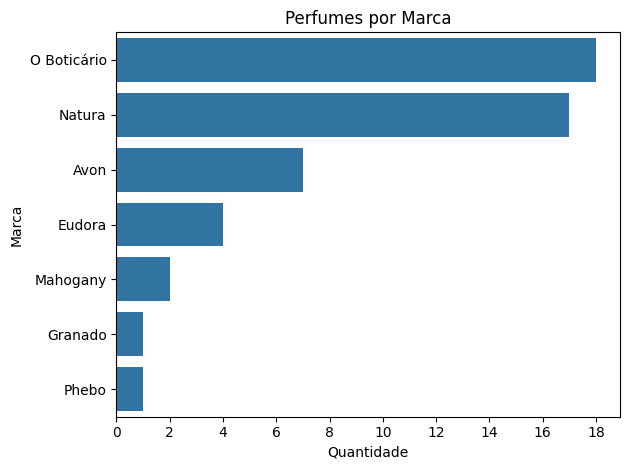

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x="total", y="marca", data=perfume_por_marca)
plt.title("Perfumes por Marca")
plt.xlabel("Quantidade")
plt.ylabel("Marca")
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

 Boticário e Natura dominam aparecem mais vezes no catálogo.
 Avon contribui com 7 perfumes, Eudora com 4, Mahogany com 2, Granado e Phebo com 1 cada.

In [ ]:
# agrupando perfume por familia olfativa para plotar
perfume_por_familia = df_produtos.groupby(['familia_olfativa']).agg(total=('nome','count')).sort_values('total', ascending=False).reset_index()
perfume_por_familia

,familia_olfativa,total
0,amadeirado aromatico,8
1,floral,7
2,amadeirado,4
3,aromatico aquatico,3
4,aromatico,3
5,floral oriental,3
6,amadeirado oriental,3
7,gourmand,2
8,chipre frutal,2
9,floral frutal,2


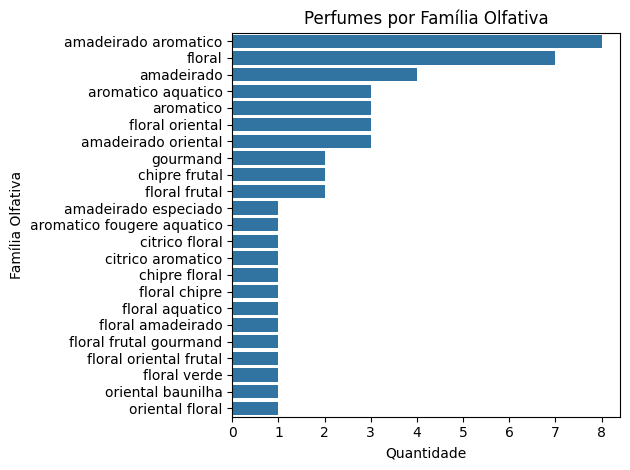

In [ ]:
sns.barplot(x="total", y="familia_olfativa", data=perfume_por_familia)
plt.title("Perfumes por Família Olfativa")
plt.xlabel("Quantidade")
plt.ylabel("Família Olfativa")
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

 O catálogo é bastante diversificado: 23 famílias olfativas diferentes. As mais representadas são
 amadeirado aromático e floral. A maioria das famílias porém aparece apenas uma vez

In [ ]:
# agrupando perfume por genero para plotar
perfume_por_genero = df_produtos.groupby(['genero']).agg(total=('nome','count')).sort_values('total', ascending=False).reset_index()
perfume_por_genero

,genero,total
0,feminino,26
1,masculino,24


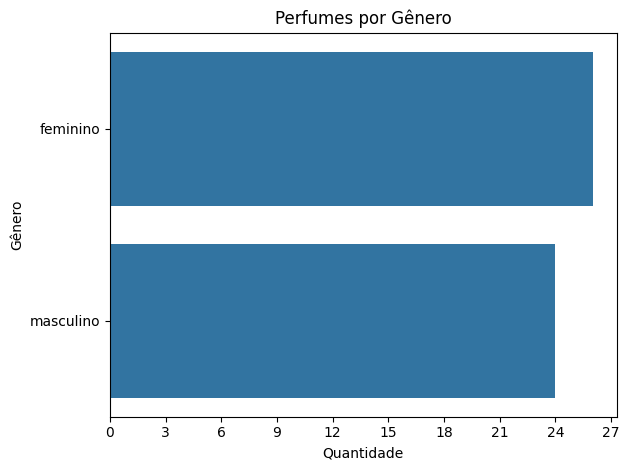

In [ ]:
sns.barplot(x="total", y="genero", data=perfume_por_genero)
plt.title("Perfumes por Gênero")
plt.xlabel("Quantidade")
plt.ylabel("Gênero")
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

 O catálogo é equilibrado entre feminino e masculino, com 26 femininos e 24 masculinos.

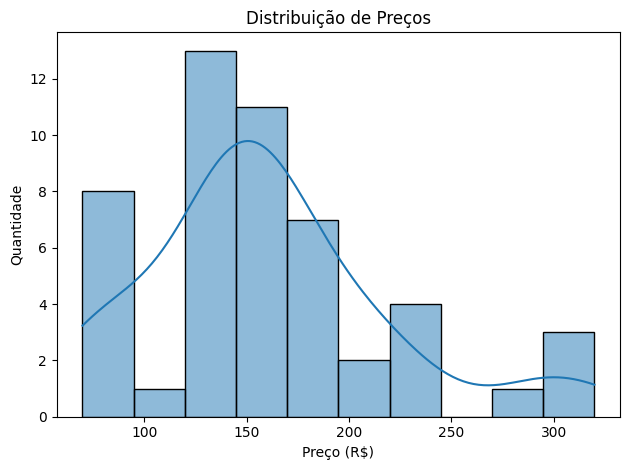

In [ ]:
sns.histplot(data=df_produtos, x="preco", kde=True)
plt.title("Distribuição de Preços")
plt.xlabel("Preço (R$)")
plt.ylabel("Quantidade")
plt.tight_layout()
plt.show()

 A distribuição de preços é assimétrica a direita. A maioria dos perfumes se concentra entre R$120 e R$170,
 com uma cauda de produtos premium acima de R$250.

 ### 2.3 Análise da matriz de utilidade

 Antes de analisar as notas é verificado quantas células não foram avaliadas.
 Isso é esperado em sistemas de recomendação reais: usuários avaliam apenas uma pequena fração dos produtos disponíveis.
 Os zeros serão excluídos nas análises seguintes pois representam ausência de avaliação, não uma nota ruim.

In [ ]:
total = df_matriz.size # total de combinaçoes da matriz
nao_avaliados = (df_matriz == 0).sum().sum() # conta o total de celulas zeradas na matriz
avaliados = total - nao_avaliados # calcula as combinacoes que tem nota de 1 a 5 
media_por_usuario = avaliados / df_matriz.shape[0] # calcula a media de perfumes avaliados por usuario
silenciosos = (df_matriz.sum(axis=1) == 0).sum() # conta os usuarios que nao avaliaram nenhum perfume

print(f"Total de combinações possíveis (usuários x perfumes): {total}")
print(f"Combinações avaliadas (nota 1-5):  {avaliados} ({avaliados/total*100:.1f}%)")
print(f"Combinações não avaliadas (nota 0): {nao_avaliados} ({nao_avaliados/total*100:.1f}%)")
print(f"Média de perfumes avaliados por usuário: {media_por_usuario:.1f}")
print(f"Usuários que nunca avaliaram nenhum perfume: {silenciosos} ({silenciosos/df_matriz.shape[0]*100:.1f}%)")

Total de combinações possíveis (usuários x perfumes): 25000
Combinações avaliadas (nota 1-5):  5905 (23.6%)
Combinações não avaliadas (nota 0): 19095 (76.4%)
Média de perfumes avaliados por usuário: 11.8
Usuários que nunca avaliaram nenhum perfume: 51 (10.2%)


 A maioria dos usuários avaliou apenas uma pequena fração dos 50 perfumes disponíveis, o que é esperado em lojas reais.
 Uma parcela dos usuários não avaliou nenhum produto. Os dados foram gerados dessa forma para simular
 compradores reais que nunca deixam avaliação, tornando a matriz mais próxima de um cenário real.

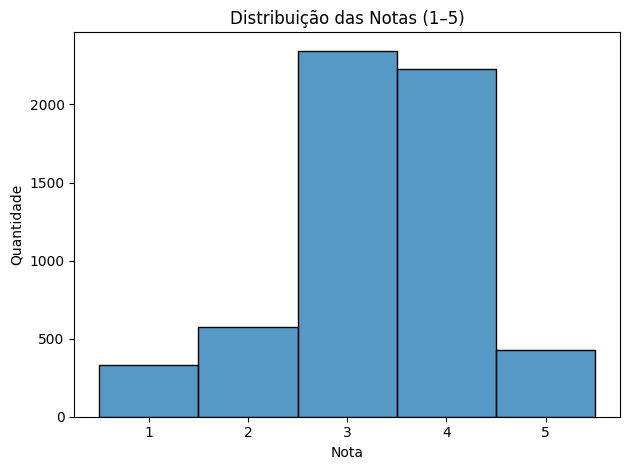

In [ ]:
notas = df_matriz.values.flatten()
notas = notas[notas > 0]  # exclui zeros (não avaliados)

sns.histplot(notas, bins=5, discrete=True)
plt.title("Distribuição das Notas (1–5)")
plt.xlabel("Nota")
plt.ylabel("Quantidade")
plt.tight_layout()
plt.show()

As notas concentram-se entre 3 e 4, sugerindo uma tendência de avaliações positivas moderadas.
Notas extremas (1 e 5) são menos frequentes, o que é comum em sistemas de avaliação reais.

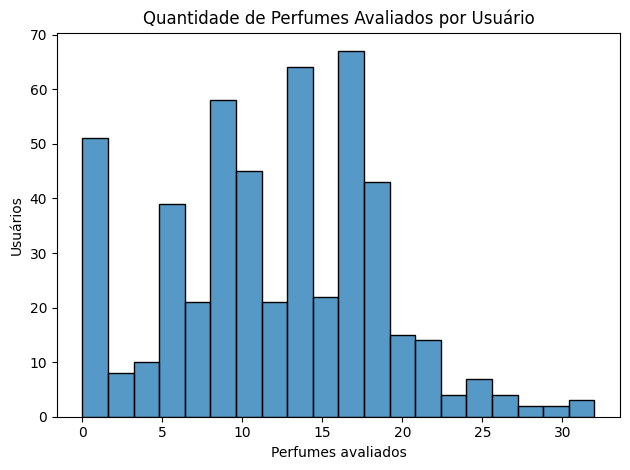

In [ ]:
avaliacoes_por_usuario = (df_matriz > 0).sum(axis=1)

sns.histplot(avaliacoes_por_usuario, bins=20)
plt.title("Quantidade de Perfumes Avaliados por Usuário")
plt.xlabel("Perfumes avaliados")
plt.ylabel("Usuários")
plt.tight_layout()
plt.show()

 A maioria dos usuários avaliou entre 5 e 20 perfumes. Os 66 usuários que não avaliaram nenhum
perfume aparecem na barra mais a esquerda. Poucos usuários avaliaram mais de 25 perfumes,
o que é esperado em um cenário de compras real.

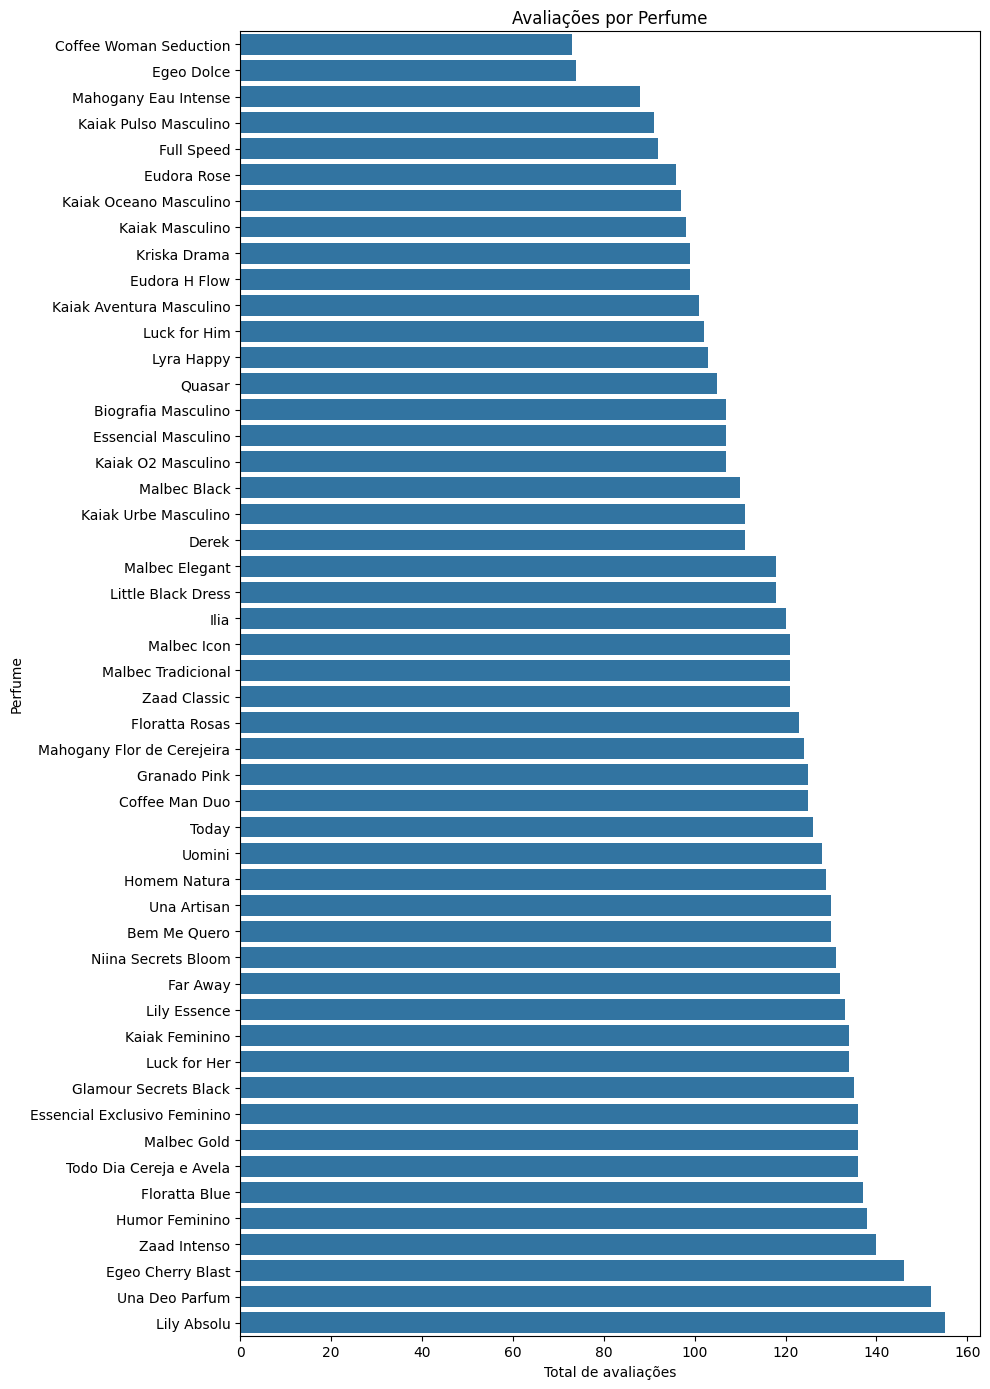

In [ ]:
avaliacoes_por_perfume = (df_matriz > 0).sum(axis=0).reset_index()
avaliacoes_por_perfume.columns = ['perfume_id', 'total_avaliacoes']
avaliacoes_por_perfume['id'] = avaliacoes_por_perfume['perfume_id'].str.extract(r'(\d+)').astype(int)
avaliacoes_por_perfume = avaliacoes_por_perfume.merge(
      df_produtos[['id', 'nome', 'genero', 'familia_olfativa', 'ocasiao']], on='id'
)

plt.figure(figsize=(10, 14))
sns.barplot(x='total_avaliacoes', y='nome',
            data=avaliacoes_por_perfume.sort_values('total_avaliacoes', ascending=True))
plt.title("Avaliações por Perfume")
plt.xlabel("Total de avaliações")
plt.ylabel("Perfume")
plt.tight_layout()
plt.show()

In [ ]:
print('Média de avaliações por gênero')
print(avaliacoes_por_perfume.groupby('genero')['total_avaliacoes'].mean().round(1))

Média de avaliações por gênero
genero
feminino     124.6
masculino    111.0
Name: total_avaliacoes, dtype: float64


 Perfumes femininos recebem em média 124,6 avaliações contra 111,0 dos masculinos.
 A diferença de ~12% pode indicar maior engajamento do público feminino na simulação,
 possivelmente porque há mais personas femininas geradas

 ## 3. Treinamento do modelo

 ### 3.1 TF-IDF (filtragem por conteúdo)

 Primeiro a ideia é criar o vetor corpus para que o TF-IDF consiga transformar os perfumes em vetores.
  Essa transformação precisa juntar os textos das colunas familia_olfativa, notas_olfativas, ocasiao e genero.

 As colunas marca e nome servirão apenas para visualização na interface e a coluna preço servirá como filtro mais futuramente.
  Como o TF-IDF recebe somente texto e o preço é um dado do tipo float, ele não pode entrar nesse vetor corpus.

In [ ]:
import unicodedata

def clean_text(texto):
    texto = str(texto).lower() # transforma para minuscula
    # separa a letra do acento e remove o acento ignorando tudo que nao é ascii
    texto = unicodedata.normalize('NFKD', texto).encode('ascii', 'ignore').decode('utf-8')
    texto = texto.replace(',', '') # remove virgula
    texto = texto.replace('-', ' ') # remove hifen
    return texto

 A função clean_text normaliza o texto convertendo para minúsculo, removendo acentos via unicodedata,
 removendo vírgulas das notas olfativas e substituindo hífens por espaços na ocasião,
 para que noturno-formal vire noturno formal e o TF-IDF trate cada token separadamente.

In [ ]:
df_produtos['familia_olfativa'] = df_produtos['familia_olfativa'].apply(clean_text)
df_produtos['notas_olfativas'] = df_produtos['notas_olfativas'].apply(clean_text)
df_produtos['ocasiao'] = df_produtos['ocasiao'].apply(clean_text)
df_produtos['genero'] = df_produtos['genero'].apply(clean_text)

In [ ]:
df_produtos.head()

,id,nome,marca,genero,familia_olfativa,notas_olfativas,ocasiao,preco,imagem_path
0,1,Malbec Tradicional,O Boticário,masculino,amadeirado aromatico,bergamota lavanda cedro vetiver patchouli,noturno formal,189.9,imagens/01_malbec_tradicional
1,2,Malbec Black,O Boticário,masculino,amadeirado especiado,canela pimenta rosa cedro couro whisky,noturno inverno,179.9,imagens/02_malbec_black
2,3,Lily Essence,O Boticário,feminino,floral,lirio rosa iris ambar baunilha,noturno formal,159.9,imagens/03_lily_essence
3,4,Lily Absolu,O Boticário,feminino,floral oriental,lirio jasmim patchouli baunilha ambar,noturno inverno,319.9,imagens/04_lily_absolu
4,5,Coffee Man Duo,O Boticário,masculino,amadeirado aromatico,cafe bergamota gengibre patchouli sandalo,diurno casual,149.9,imagens/05_coffee_man_duo


 A normalização é aplicada nas quatro colunas que formarão o corpus.

In [ ]:
df_produtos['corpus'] = df_produtos['familia_olfativa'] + " " + df_produtos['notas_olfativas'] + " " + df_produtos['ocasiao'] + " " + df_produtos['genero']
df_produtos['corpus'].head()

0    amadeirado aromatico bergamota lavanda cedro v...
1    amadeirado especiado canela pimenta rosa cedro...
2    floral lirio rosa iris ambar baunilha noturno ...
3    floral oriental lirio jasmim patchouli baunilh...
4    amadeirado aromatico cafe bergamota gengibre p...
Name: corpus, dtype: str

 O corpus é criado concatenando as quatro colunas normalizadas em uma única string por perfume.
 Essa string representa o "documento" que o TF-IDF vai vetorizar.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

vectorizer = TfidfVectorizer()
vectorized = vectorizer.fit_transform(df_produtos['corpus'])

# matriz de similaridade de cosseno entre os 50 perfumes (50×50)
matriz_similaridade = cosine_similarity(vectorized)

print(f"Matriz TF-IDF: {vectorized.shape}")
print(f"Matriz de similaridade: {matriz_similaridade.shape}")

Matriz TF-IDF: (50, 90)
Matriz de similaridade: (50, 50)


 O TfidfVectorizer aprende o vocabulário dos 50 perfumes e transforma cada corpus em um vetor numérico.
 Palavras raras recebem peso maior que palavras comuns, o que é mais adequado que uma simples contagem.
 A matriz resultante tem dimensão 50 × 90: 50 perfumes e 90 tokens únicos no vocabulário.
 A similaridade de cosseno compara cada par de perfumes com base nos seus vetores TF-IDF,
 retornando valores entre 0 (nenhuma similaridade) e 1 (idênticos). A matriz de similaridade é 50 × 50.

In [ ]:
exemplo_idx = 0
sim_scores = list(enumerate(matriz_similaridade[exemplo_idx]))
sim_scores.sort(key=lambda x: x[1], reverse=True)

indices = [idx for idx, _ in sim_scores[1:6]]
scores  = [score for _, score in sim_scores[1:6]]

resultado = df_produtos.iloc[indices][['nome', 'marca', 'familia_olfativa', 'ocasiao', 'notas_olfativas']].copy()
resultado['similaridade'] = [round(s, 3) for s in scores]
resultado.reset_index(drop=True, inplace=True)

print(f"Perfumes mais similares a '{df_produtos.iloc[exemplo_idx]['nome']}':\n")
resultado

Perfumes mais similares a 'Malbec Tradicional':



,nome,marca,familia_olfativa,ocasiao,notas_olfativas,similaridade
0,Malbec Elegant,O Boticário,amadeirado aromatico,noturno formal,bergamota pimenta vetiver cedro ambar,0.757
1,Derek,Avon,amadeirado aromatico,diurno casual,bergamota lavanda salvia vetiver almiscar,0.624
2,Homem Natura,Natura,amadeirado aromatico,diurno formal,bergamota lavanda cedro pau rosa almiscar,0.609
3,Malbec Icon,O Boticário,amadeirado aromatico,noturno casual,bergamota limao cardamomo patchouli cedro,0.562
4,Quasar,O Boticário,amadeirado aromatico,diurno casual,bergamota lavanda salvia cedro almiscar,0.555


 A validação com o Malbec Tradicional confirma que o modelo está funcionando corretamente:
 os perfumes retornados compartilham família olfativa amadeirado aromático e notas como
 bergamota e cedro.

 ### 3.2 SVD — Filtragem colaborativa

 O SVD (Singular Value Decomposition) decompõe a matriz de avaliações (500×50) em três fatores:
 U (usuários × fatores), sigma (importância de cada fator) e Vt (fatores × perfumes).
 Os fatores latentes capturam padrões ocultos de preferência, como "usuários que gostam de
 amadeirado tendem a gostar de oriental".
 A matriz reconstruída contém previsões de nota para todos os pares usuário-perfume,
 inclusive os não avaliados, que é exatamente o que permite a filtragem colaborativa.

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

matrix = df_matriz.values.astype(float)
train_raw, test_raw = train_test_split(matrix, test_size=0.2, random_state=42)

In [ ]:
def preparar_svd(mat):
    # converte zeros para NaN (não avaliado ≠ nota 0)
    m = mat.astype(float).copy()
    m[m == 0] = np.nan

    # média global de todas as notas reais (usada para usuários silenciosos)
    media_global = np.nanmean(m)

    # média por usuário ignorando NaN
    user_means = np.nanmean(m, axis=1)
    # usuários silenciosos recebem a média global — mais honesto que um valor fixo arbitrário
    user_means = np.where(np.isnan(user_means), media_global, user_means)

    # substitui NaN pela média do próprio usuário
    m_filled = m.copy()
    for i in range(m_filled.shape[0]):
        mascara = np.isnan(m_filled[i])
        m_filled[i, mascara] = user_means[i]

    # centraliza subtraindo a média de cada usuário
    m_centered = m_filled - user_means[:, np.newaxis]

    return m_centered, user_means

 A comparação para u1 mostra que o SVD captura bem as preferências mais altas — perfumes com
 nota 5 recebem previsões entre 4.0 e 4.5. Nas notas mais baixas o modelo é menos preciso:
 o perfume com nota 1 recebeu previsão 3.10, acima de alguns com nota 2. Isso é uma limitação
 esperada do SVD com dados esparsos — a ordenação no topo é confiável, mas os extremos
 negativos são suavizados.

In [ ]:
from scipy.linalg import svd as scipy_svd

k = 15  # número de fatores latentes

# treina o SVD com o conjunto de treino
train_centered, train_means = preparar_svd(train_raw)
U, sigma, Vt = scipy_svd(train_centered, full_matrices=False)

# projeta os usuários de teste no espaço aprendido pelo treino
# W_test = test_centered @ Vt.T / sigma (equivalente ao transform do NMF)
test_centered, test_means = preparar_svd(test_raw)
W_test = test_centered @ Vt[:k, :].T / sigma[:k]
pred_test_svd = W_test @ np.diag(sigma[:k]) @ Vt[:k, :] + test_means[:, np.newaxis]
pred_test_svd = np.clip(pred_test_svd, 1.0, 5.0)

# calcula RMSE apenas nas células que tinham nota real (ignora zeros)
mask_test = test_raw > 0
rmse = np.sqrt(mean_squared_error(test_raw[mask_test], pred_test_svd[mask_test]))
print(f"RMSE no conjunto de teste: {rmse:.4f}")

# variância explicada pelos k fatores latentes
var_total = np.sum(sigma ** 2)
var_k     = np.sum(sigma[:k] ** 2)
print(f"Variância explicada pelos {k} fatores: {var_k / var_total * 100:.1f}%")

RMSE no conjunto de teste: 0.6092
Variância explicada pelos 15 fatores: 51.8%


<ipython-input-25-48f3a4b27310>:12: RuntimeWarning: Mean of empty slice
  user_means = np.nanmean(m, axis=1)


In [ ]:
# treina o SVD final com a matriz completa dos 500 usuários
mat_centered, user_means = preparar_svd(matrix)
U, sigma, Vt = np.linalg.svd(mat_centered, full_matrices=False)

# reconstrói a matriz completa de predições (500×50)
pred_matrix = U[:, :k] @ np.diag(sigma[:k]) @ Vt[:k, :] + user_means[:, np.newaxis]
pred_matrix = np.clip(pred_matrix, 1.0, 5.0)

print(f"Matriz de predições: {pred_matrix.shape}")

<ipython-input-25-48f3a4b27310>:12: RuntimeWarning: Mean of empty slice
  user_means = np.nanmean(m, axis=1)


Matriz de predições: (500, 50)


In [ ]:
# valida comparando previsão vs notas reais do usuário u1
usuario_idx = df_matriz.index.get_loc('u1')
real     = df_matriz.iloc[usuario_idx]
previsto = pd.Series(pred_matrix[usuario_idx], index=df_matriz.columns).round(2)

comparacao = pd.DataFrame({'real': real, 'previsto': previsto})
comparacao[comparacao['real'] > 0].sort_values('real', ascending=False)

,real,previsto
p16,5,4.43
p32,5,4.77
p31,5,4.25
p50,5,4.29
p12,4,3.98
p5,4,3.63
p34,4,3.83
p25,3,3.54
p11,3,3.40
p18,2,2.59


 A comparação para u1 mostra que perfumes com nota 5 recebem previsões próximas de 4.5 e
 o perfume com nota 1 recebe a menor previsão. O SVD captura bem a ordenação das preferências.
 A matriz pred_matrix será usada na função de recomendação híbrida para reordenar os candidatos
 do TF-IDF com base no gosto de usuários com perfil similar ao novo usuário.

 ### 3.3 Pipeline de recomendação híbrida

 1. O usuário informa suas preferências (família olfativa, ocasião, faixa de preço)
 2. **TF-IDF** gera os 20 perfumes candidatos mais similares ao perfil
 3. **SVD** encontra os usuários com perfil mais similar e usa as notas previstas deles
 4. Retorna os **top-5** finais com peso 70% TF-IDF + 30% SVD

In [ ]:
def recomendar_hibrido(familias_pref, ocasiao_pref, genero_pref, faixa_preco, top_n=5):

    # TF-IDF: gera score de conteúdo para o perfil do usuário
    perfil = " ".join(familias_pref) + " " + clean_text(ocasiao_pref) + " " + clean_text(genero_pref)
    perfil_vec = vectorizer.transform([perfil])
    scores_tfidf = cosine_similarity(perfil_vec, vectorized).flatten()

    # filtro de gênero
    mask = df_produtos['genero'] == clean_text(genero_pref)

    # filtro de preço
    if faixa_preco == 'ate_100':
        mask &= df_produtos['preco'] <= 100
    elif faixa_preco == '100_200':
        mask &= (df_produtos['preco'] > 100) & (df_produtos['preco'] <= 200)
    elif faixa_preco == '200_300':
        mask &= (df_produtos['preco'] > 200) & (df_produtos['preco'] <= 300)
    else:
        mask &= df_produtos['preco'] > 300

    # se nenhum perfume passar no filtro de preço, ignora o filtro
    if mask.sum() == 0:
        mask = df_produtos['genero'] == clean_text(genero_pref)

    # top-20 candidatos pelo TF-IDF
    indices = df_produtos[mask].index.tolist()
    candidatos = sorted([(i, scores_tfidf[i]) for i in indices],
                        key=lambda x: x[1], reverse=True)[:20]
    top20 = [i for i, _ in candidatos]

    # SVD: encontra os 50 usuários cujas notas previstas mais se alinham ao perfil do novo usuário
    # usando os scores TF-IDF dos candidatos como proxy do perfil
    scores_perfil = scores_tfidf[top20]
    pesos_usuarios = pred_matrix[:, top20] @ scores_perfil  # alinhamento de cada usuário ao perfil
    top_usuarios = np.argsort(pesos_usuarios)[::-1][:50]    # top-50 usuários mais similares
    svd_scores = pred_matrix[top_usuarios][:, top20].mean(axis=0)  # média das notas deles

    # combinação: 70% TF-IDF + 30% SVD (SVD normalizado para 0-1)
    resultado = []
    for rank, idx in enumerate(top20):
        tfidf_s = scores_tfidf[idx]
        svd_s   = (svd_scores[rank] - 1) / 4  # normaliza 1-5 → 0-1
        final   = 0.7 * tfidf_s + 0.3 * svd_s
        resultado.append((idx, final, svd_scores[rank]))

    resultado.sort(key=lambda x: x[1], reverse=True)

    print(f"\n{'='*60}")
    print(f"Recomendações — {', '.join(familias_pref)} | {ocasiao_pref} | {genero_pref}")
    print(f"{'='*60}")
    for i, (idx, score, nota) in enumerate(resultado[:top_n], 1):
        row = df_produtos.iloc[idx]
        print(f"  {i}. {row['nome']} ({row['marca']}) — R${row['preco']:.2f}")
        print(f"     Família: {row['familia_olfativa']} | Nota SVD: {nota:.1f} | Score: {score:.3f}")

    return resultado[:top_n]

In [ ]:
# teste do pipeline
recomendar_hibrido(['amadeirado aromatico'], 'noturno-formal', 'masculino', '100_200')


Recomendações — amadeirado aromatico | noturno-formal | masculino
  1. Malbec Tradicional (O Boticário) — R$189.90
     Família: amadeirado aromatico | Nota SVD: 4.0 | Score: 0.653
  2. Mahogany Eau Intense (Mahogany) — R$149.90
     Família: amadeirado | Nota SVD: 4.0 | Score: 0.585
  3. Homem Natura (Natura) — R$139.90
     Família: amadeirado aromatico | Nota SVD: 4.2 | Score: 0.575
  4. Malbec Icon (O Boticário) — R$199.90
     Família: amadeirado aromatico | Nota SVD: 4.2 | Score: 0.570
  5. Quasar (O Boticário) — R$139.90
     Família: amadeirado aromatico | Nota SVD: 4.2 | Score: 0.491


[(0, np.float64(0.6530226842379927), np.float64(4.016934950684354)),
 (49, np.float64(0.5852393336357622), np.float64(4.027180667503876)),
 (24, np.float64(0.5754033137510028), np.float64(4.1739734018574435)),
 (33, np.float64(0.5698103438105657), np.float64(4.185406049803876)),
 (10, np.float64(0.4911600924699896), np.float64(4.159434372384203))]

 ## 4. Salvamento dos modelos

 Os modelos são salvos em disco para que o app.py (Gradio) possa carregá-los diretamente,
 sem precisar retreinar toda vez que a interface for aberta.

 São salvos:
 - **vectorizer** — o TfidfVectorizer treinado, necessário para vetorizar o perfil do novo usuário
 - **vectorized** — a matriz TF-IDF dos 50 perfumes (50×90), usada no cálculo de similaridade
 - **pred_matrix** — a matriz SVD de predições (500×50), usada para reordenar os candidatos
 - **df_produtos** — o catálogo já normalizado, com a coluna corpus criada

In [ ]:
import joblib
import os

os.makedirs('../modelos', exist_ok=True)

joblib.dump(vectorizer,  '../modelos/tfidf_vectorizer.pkl')
joblib.dump(vectorized,  '../modelos/tfidf_matrix.pkl')
joblib.dump(pred_matrix, '../modelos/svd_pred_matrix.pkl')
df_produtos.to_csv('../dados/produtos_processados.csv', index=False)

print("Modelos salvos em ../modelos/")
print(f" tfidf_vectorizer.pkl")
print(f" tfidf_matrix.pkl")
print(f" svd_pred_matrix.pkl")
print(f"../dados/produtos_processados.csv")

Modelos salvos em ../modelos/
 tfidf_vectorizer.pkl
 tfidf_matrix.pkl
 svd_pred_matrix.pkl
../dados/produtos_processados.csv


 ## 5. Interface Gradio

 A interface é construída com a biblioteca Gradio e combina todas as etapas anteriores em um
 aplicativo interativo. O usuário se cadastra com seu perfil olfativo e recebe recomendações
 personalizadas geradas pelo pipeline TF-IDF + SVD.

 O sistema possui três abas principais:
 - **Portal do Cliente** — cadastro, login e edição de perfil
 - **Minha Vitrine** — geração das recomendações e simulação de pedido
 - **Feedback** — avaliação (1–5 estrelas) e review textual dos perfumes pedidos

 Um sistema de fallback em cascata garante que o usuário sempre receba sugestões, mesmo
 quando os critérios são muito restritivos:
 - Nível 0: TF-IDF + SVD com todas as restrições
 - Nível 1: Remove restrição de ocasião
 - Nível 2: Remove restrição de gênero
 - Nível 3: Retorna os 5 perfumes mais vendidos (mockados)

In [ ]:
# imports adicionais necessários para a interface
import warnings
warnings.filterwarnings("ignore")

import csv
import json
import base64
import gradio as gr
from pathlib import Path

# BASE aponta para a raiz do projeto (um nível acima de scripts/)
BASE          = Path("..").resolve()
USUARIOS_JSON = BASE / "usuarios.json"
FEEDBACK_CSV  = BASE / "dados" / "feedback.csv"

import pandas as pd
import joblib

# import dos modelos e dos produtos
df_produtos = pd.read_csv(BASE / "dados" / "produtos_processados.csv")
vectorizer  = joblib.load(BASE / "modelos" / "tfidf_vectorizer.pkl")
vectorized  = joblib.load(BASE / "modelos" / "tfidf_matrix.pkl")
pred_matrix = joblib.load(BASE / "modelos" / "svd_pred_matrix.pkl")

# listas para os widgets do Gradio — derivadas do catálogo já carregado em memória
FAMILIAS = sorted(df_produtos["familia_olfativa"].unique().tolist())
OCASIOES = sorted(df_produtos["ocasiao"].unique().tolist())
GENEROS  = ["feminino", "masculino"]

In [ ]:
# funções auxiliares de recomendação

def formatar_estrelas(nota):
    arredondado = int(round(nota))
    return "★" * arredondado + "☆" * (5 - arredondado)


def obter_top5_mockados(genero_pref):
    """Retorna os 5 perfumes mais vendidos mockados por gênero (fallback nível 3)."""
    top5_por_genero = {
        "feminino": [
            (18, 4.8, 4.8),  # Kaiak Feminino
            (2,  4.6, 4.6),  # Lily Essence
            (5,  4.7, 4.7),  # Coffee Woman Seduction
            (16, 4.5, 4.5),  # Essencial Exclusivo Feminino
            (6,  4.6, 4.6),  # Floratta Rosas
        ],
        "masculino": [
            (10, 4.7, 4.7),  # Quasar
            (0,  4.8, 4.8),  # Malbec Tradicional
            (4,  4.6, 4.6),  # Coffee Man Duo
            (17, 4.7, 4.7),  # Kaiak Masculino
            (15, 4.5, 4.5),  # Essencial Masculino
        ]
    }
    return top5_por_genero.get(genero_pref, top5_por_genero["feminino"])


def validar_inputs(familias_pref, ocasiao_pref, genero_pref, preco_max):
    """Normaliza os inputs e preenche valores padrão quando necessário."""
    if not familias_pref:
        familias_pref = ["floral"]
    if not ocasiao_pref or ocasiao_pref == "null":
        ocasiao_pref = "diurno casual"
    if not genero_pref or genero_pref not in ["feminino", "masculino"]:
        genero_pref = "feminino"
    if preco_max is None or preco_max <= 0:
        preco_max = 200
    return familias_pref, ocasiao_pref, genero_pref, preco_max

In [ ]:
# pipeline de recomendação híbrida com suporte a preco_max direto (versão interface)
# redefine a função do notebook, que usava faixa_preco categórica

def recomendar_hibrido(familias_pref, ocasiao_pref, genero_pref, preco_max, top_n=5):
    familias_pref, ocasiao_pref, genero_pref, preco_max = validar_inputs(
        familias_pref, ocasiao_pref, genero_pref, preco_max
    )
    perfil     = " ".join(familias_pref) + " " + ocasiao_pref + " " + genero_pref
    perfil_vec = vectorizer.transform([perfil])
    scores_tfidf = cosine_similarity(perfil_vec, vectorized).flatten()

    mask = (df_produtos["genero"] == genero_pref) & (df_produtos["preco"] <= preco_max)
    indices   = df_produtos[mask].index.tolist()
    candidatos = sorted([(i, scores_tfidf[i]) for i in indices], key=lambda x: x[1], reverse=True)[:20]

    if not candidatos:
        return [], False

    top20          = [i for i, _ in candidatos]
    scores_perfil  = scores_tfidf[top20]
    pesos_usuarios = pred_matrix[:, top20] @ scores_perfil
    top_usuarios   = np.argsort(pesos_usuarios)[::-1][:50]
    svd_scores     = pred_matrix[top_usuarios][:, top20].mean(axis=0)

    resultado = []
    for rank, idx in enumerate(top20):
        tfidf_s = scores_tfidf[idx]
        svd_s   = (svd_scores[rank] - 1) / 4  # normaliza 1-5 → 0-1
        final   = 0.7 * tfidf_s + 0.3 * svd_s
        resultado.append((idx, final, svd_scores[rank]))

    resultado.sort(key=lambda x: x[1], reverse=True)
    return resultado[:top_n], False


def recomendar_com_fallback(familias_pref, ocasiao_pref, genero_pref, preco_max, top_n=5):
    """
    Tenta recomendar em cascata, relaxando critérios progressivamente:
    nível 0 (completo) → nível 1 (sem ocasião) → nível 2 (sem gênero) → nível 3 (mockados).
    """
    familias_pref, ocasiao_pref, genero_pref, preco_max = validar_inputs(
        familias_pref, ocasiao_pref, genero_pref, preco_max
    )
    SCORE_MINIMO = 0.50

    # Nível 0 — todas as restrições
    resultado, _ = recomendar_hibrido(familias_pref, ocasiao_pref, genero_pref, preco_max, top_n)
    if resultado and resultado[0][1] >= SCORE_MINIMO:
        familia_principal = familias_pref[0].lower()
        for idx, _, _ in resultado:
            if familia_principal in df_produtos.iloc[idx]["familia_olfativa"].lower():
                return resultado, 0, "✅ Recomendação personalizada com excelente match!"

    # Nível 1 — remove ocasião
    perfil_vec   = vectorizer.transform([" ".join(familias_pref) + " " + genero_pref])
    scores_tfidf = cosine_similarity(perfil_vec, vectorized).flatten()
    mask = (df_produtos["genero"] == genero_pref) & (df_produtos["preco"] <= preco_max)
    if mask.sum() > 0:
        top20 = [i for i, _ in sorted([(i, scores_tfidf[i]) for i in df_produtos[mask].index],
                                       key=lambda x: x[1], reverse=True)[:20]]
        svd_scores = pred_matrix[np.argsort(pred_matrix[:, top20] @ scores_tfidf[top20])[::-1][:50]][:, top20].mean(axis=0)
        resultado  = sorted([(top20[r], 0.7*scores_tfidf[top20[r]] + 0.3*(svd_scores[r]-1)/4, svd_scores[r])
                              for r in range(len(top20))], key=lambda x: x[1], reverse=True)[:top_n]
        if resultado and resultado[0][1] >= SCORE_MINIMO:
            return resultado, 1, "⚠️ Poucas opções para essa ocasião. Mostrando recomendações de outras ocasiões."

    # Nível 2 — remove gênero
    perfil_vec   = vectorizer.transform([" ".join(familias_pref) + " " + ocasiao_pref])
    scores_tfidf = cosine_similarity(perfil_vec, vectorized).flatten()
    mask = df_produtos["preco"] <= preco_max
    if mask.sum() > 0:
        top20 = [i for i, _ in sorted([(i, scores_tfidf[i]) for i in df_produtos[mask].index],
                                       key=lambda x: x[1], reverse=True)[:20]]
        svd_scores = pred_matrix[np.argsort(pred_matrix[:, top20] @ scores_tfidf[top20])[::-1][:50]][:, top20].mean(axis=0)
        resultado  = sorted([(top20[r], 0.7*scores_tfidf[top20[r]] + 0.3*(svd_scores[r]-1)/4, svd_scores[r])
                              for r in range(len(top20))], key=lambda x: x[1], reverse=True)[:top_n]
        if resultado and resultado[0][1] >= SCORE_MINIMO:
            return resultado, 2, "⚠️ Poucos perfumes no seu gênero. Mostrando recomendações de outras categorias."

    # Nível 3 — top-5 mockados
    return obter_top5_mockados(genero_pref)[:top_n], 3, "📌 Mostrando os 5 perfumes mais vendidos da comunidade!"

In [ ]:
# funções de autenticação e persistência de usuários

def carregar_usuarios():
    if USUARIOS_JSON.exists():
        conteudo = USUARIOS_JSON.read_text(encoding="utf-8").strip()
        if conteudo:
            return json.loads(conteudo)
    return {}


def salvar_usuarios(dados):
    USUARIOS_JSON.write_text(json.dumps(dados, ensure_ascii=False, indent=2), encoding="utf-8")


def auth_output_payload(status_msg, msg_bem_vindo, auth_visible, perfil_visible,
                        email, nome, genero, familia, ocasiao, preco_max):
    return (
        status_msg, msg_bem_vindo,
        gr.update(visible=auth_visible),
        gr.update(visible=perfil_visible),
        gr.update(visible=perfil_visible),  # vitrine_auth
        gr.update(visible=auth_visible),    # vitrine_anon
        gr.update(visible=perfil_visible),  # feedback_auth
        gr.update(visible=auth_visible),    # feedback_anon
        email, nome, genero, familia, ocasiao, preco_max
    )


def cadastrar(email, senha, nome, genero, familia, ocasiao, preco_max):
    if not email or not senha or not nome:
        return auth_output_payload("⚠️ Preencha e-mail, senha e nome.", "", True, False, None, None, None, [], None, 200)
    if not familia:
        return auth_output_payload("⚠️ Selecione pelo menos uma família olfativa.", "", True, False, None, None, None, [], None, 200)
    if not ocasiao:
        return auth_output_payload("⚠️ Selecione uma ocasião de uso.", "", True, False, None, None, None, [], None, 200)
    if not genero:
        return auth_output_payload("⚠️ Selecione um gênero de perfume.", "", True, False, None, None, None, [], None, 200)
    usuarios = carregar_usuarios()
    if email in usuarios:
        return auth_output_payload("⚠️ E-mail já cadastrado. Faça login.", "", True, False, None, None, None, [], None, 200)
    usuarios[email] = {"senha": senha, "nome": nome, "genero": genero,
                       "familia": familia, "ocasiao": ocasiao, "preco_max": preco_max}
    salvar_usuarios(usuarios)
    info_html = f"""
    <div style="background:linear-gradient(145deg,#1c1829,#252137);border-radius:12px;padding:24px;border:1px solid rgba(201,169,110,0.3);margin:20px 0;box-shadow:0 8px 32px rgba(0,0,0,0.3);">
        <h3 style="color:#c9a96e;margin-top:0;font-size:20px;">✅ Conta criada com sucesso, {nome}!</h3>
        <div style="display:grid;grid-template-columns:1fr 1fr;gap:12px;margin-top:16px;">
            <div style="background:rgba(0,0,0,0.2);padding:12px;border-radius:8px;">
                <span style="color:#8a7f9e;font-size:11px;text-transform:uppercase;letter-spacing:1px;">🧬 Gênero</span><br>
                <span style="color:#e8d5b7;font-weight:bold;">{genero}</span>
            </div>
            <div style="background:rgba(0,0,0,0.2);padding:12px;border-radius:8px;">
                <span style="color:#8a7f9e;font-size:11px;text-transform:uppercase;letter-spacing:1px;">📍 Ocasião</span><br>
                <span style="color:#e8d5b7;font-weight:bold;">{ocasiao}</span>
            </div>
            <div style="background:rgba(0,0,0,0.2);padding:12px;border-radius:8px;">
                <span style="color:#8a7f9e;font-size:11px;text-transform:uppercase;letter-spacing:1px;">💰 Preço Máx</span><br>
                <span style="color:#e8d5b7;font-weight:bold;">R$ {preco_max:.2f}</span>
            </div>
            <div style="background:rgba(0,0,0,0.2);padding:12px;border-radius:8px;">
                <span style="color:#8a7f9e;font-size:11px;text-transform:uppercase;letter-spacing:1px;">🌸 Famílias Favoritas</span><br>
                <span style="color:#e8d5b7;font-weight:bold;">{', '.join(familia)}</span>
            </div>
        </div>
    </div>
    """
    return auth_output_payload("", info_html, False, True, email, nome, genero, familia, ocasiao, preco_max)


def login(email, senha):
    if not email or not senha:
        return auth_output_payload("⚠️ Digite e-mail e senha.", "", True, False, None, None, None, [], None, 200)
    usuarios = carregar_usuarios()
    if email not in usuarios:
        return auth_output_payload("❌ E-mail não encontrado. Cadastre-se primeiro.", "", True, False, None, None, None, [], None, 200)
    u = usuarios[email]
    if u.get("senha") != senha:
        return auth_output_payload("❌ Senha incorreta.", "", True, False, None, None, None, [], None, 200)
    familia = u["familia"] if isinstance(u["familia"], list) else [u["familia"]]
    info_html = f"""
    <div style="background:linear-gradient(145deg,#1c1829,#252137);border-radius:12px;padding:24px;border:1px solid rgba(201,169,110,0.3);margin:20px 0;box-shadow:0 8px 32px rgba(0,0,0,0.3);">
        <h3 style="color:#c9a96e;margin-top:0;font-size:20px;">✅ Bem-vindo(a) de volta, {u['nome']}!</h3>
        <div style="display:grid;grid-template-columns:1fr 1fr;gap:12px;margin-top:16px;">
            <div style="background:rgba(0,0,0,0.2);padding:12px;border-radius:8px;">
                <span style="color:#8a7f9e;font-size:11px;text-transform:uppercase;letter-spacing:1px;">🧬 Gênero</span><br>
                <span style="color:#e8d5b7;font-weight:bold;">{u['genero']}</span>
            </div>
            <div style="background:rgba(0,0,0,0.2);padding:12px;border-radius:8px;">
                <span style="color:#8a7f9e;font-size:11px;text-transform:uppercase;letter-spacing:1px;">📍 Ocasião</span><br>
                <span style="color:#e8d5b7;font-weight:bold;">{u['ocasiao']}</span>
            </div>
            <div style="background:rgba(0,0,0,0.2);padding:12px;border-radius:8px;">
                <span style="color:#8a7f9e;font-size:11px;text-transform:uppercase;letter-spacing:1px;">💰 Preço Máx</span><br>
                <span style="color:#e8d5b7;font-weight:bold;">R$ {u['preco_max']:.2f}</span>
            </div>
            <div style="background:rgba(0,0,0,0.2);padding:12px;border-radius:8px;">
                <span style="color:#8a7f9e;font-size:11px;text-transform:uppercase;letter-spacing:1px;">🌸 Famílias Favoritas</span><br>
                <span style="color:#e8d5b7;font-weight:bold;">{', '.join(familia)}</span>
            </div>
        </div>
    </div>
    """
    return auth_output_payload("", info_html, False, True, email, u["nome"], u["genero"], familia, u["ocasiao"], u["preco_max"])


def logout():
    return auth_output_payload("", "", True, False, None, None, None, [], None, 200)


def atualizar_perfil(email, genero, familia, ocasiao, preco_max):
    if not email:
        return "⚠️ Usuário não identificado.", gr.update(), genero, familia, ocasiao, preco_max
    if not familia:
        return "⚠️ Selecione pelo menos uma família olfativa.", gr.update(), genero, familia, ocasiao, preco_max
    if not ocasiao:
        return "⚠️ Selecione uma ocasião de uso.", gr.update(), genero, familia, ocasiao, preco_max
    if not genero:
        return "⚠️ Selecione um gênero de perfume.", gr.update(), genero, familia, ocasiao, preco_max
    usuarios = carregar_usuarios()
    usuarios[email].update({"genero": genero, "familia": familia, "ocasiao": ocasiao, "preco_max": preco_max})
    salvar_usuarios(usuarios)
    nome = usuarios[email]["nome"]
    info_html = f"""
    <div style="background:linear-gradient(145deg,#1c1829,#252137);border-radius:12px;padding:24px;border:1px solid rgba(201,169,110,0.3);margin:20px 0;box-shadow:0 8px 32px rgba(0,0,0,0.3);">
        <h3 style="color:#c9a96e;margin-top:0;font-size:20px;">✅ Preferências atualizadas, {nome}!</h3>
        <div style="display:grid;grid-template-columns:1fr 1fr;gap:12px;margin-top:16px;">
            <div style="background:rgba(0,0,0,0.2);padding:12px;border-radius:8px;">
                <span style="color:#8a7f9e;font-size:11px;text-transform:uppercase;letter-spacing:1px;">🧬 Gênero</span><br>
                <span style="color:#e8d5b7;font-weight:bold;">{genero}</span>
            </div>
            <div style="background:rgba(0,0,0,0.2);padding:12px;border-radius:8px;">
                <span style="color:#8a7f9e;font-size:11px;text-transform:uppercase;letter-spacing:1px;">📍 Ocasião</span><br>
                <span style="color:#e8d5b7;font-weight:bold;">{ocasiao}</span>
            </div>
            <div style="background:rgba(0,0,0,0.2);padding:12px;border-radius:8px;">
                <span style="color:#8a7f9e;font-size:11px;text-transform:uppercase;letter-spacing:1px;">💰 Preço Máx</span><br>
                <span style="color:#e8d5b7;font-weight:bold;">R$ {preco_max:.2f}</span>
            </div>
            <div style="background:rgba(0,0,0,0.2);padding:12px;border-radius:8px;">
                <span style="color:#8a7f9e;font-size:11px;text-transform:uppercase;letter-spacing:1px;">🌸 Famílias Favoritas</span><br>
                <span style="color:#e8d5b7;font-weight:bold;">{', '.join(familia)}</span>
            </div>
        </div>
    </div>
    """
    return "✅ Perfil atualizado com sucesso!", info_html, genero, familia, ocasiao, preco_max

In [ ]:
# funções de vitrine e feedback

def gerar_vitrine(nome, genero, familias, ocasiao, preco_max):
    out_cols   = [gr.update(visible=False)] * 5
    out_htmls  = [gr.update(value="")] * 5
    out_checks = [gr.update(value=False)] * 5
    out_nomes  = [""] * 5

    if not familias:
        return [gr.update(value="<p style='text-align:center;color:#888;padding:60px;'>Seu perfil não tem famílias olfativas cadastradas.</p>")] + out_cols + out_htmls + out_checks + out_nomes + [gr.update(visible=False)]

    tops, nivel_fallback, msg_fallback = recomendar_com_fallback(familias, ocasiao, genero, preco_max)

    for i in range(5):
        if i < len(tops):
            rank = i + 1
            idx, score, nota_svd = tops[i]
            r          = df_produtos.iloc[idx]
            stars      = formatar_estrelas(nota_svd)
            notas      = r["notas_olfativas"].split(", ")
            notas_html = "".join(
                f'<span style="background:rgba(201,169,110,0.15);color:#c9a96e;padding:2px 8px;border-radius:20px;font-size:11px;margin:2px;">{n}</span>'
                for n in notas[:4]
            )
            img_prefix   = r.get("imagem_path", "")
            img_html     = '<div style="font-size:56px;opacity:0.9;">🧴</div>'
            lightbox_html = ""
            if pd.notna(img_prefix) and img_prefix:
                matches = list(BASE.glob(f"{img_prefix}.*"))
                if matches:
                    try:
                        encoded  = base64.b64encode(matches[0].read_bytes()).decode("utf-8")
                        ext      = matches[0].suffix.lower().lstrip(".")
                        if ext == "jpg": ext = "jpeg"
                        data_src = f"data:image/{ext};base64,{encoded}"
                        img_html = f'<img src="{data_src}" style="width:100%;height:100%;object-fit:cover;opacity:0.9;cursor:zoom-in;" onclick="document.getElementById(\'lbx_{i}\').style.display=\'flex\'" title="Clique para ampliar" />'
                        lightbox_html = f'<div id="lbx_{i}" onclick="this.style.display=\'none\'" style="display:none;position:fixed;inset:0;z-index:9999;background:rgba(0,0,0,0.92);align-items:center;justify-content:center;cursor:zoom-out;"><img src="{data_src}" style="max-height:90vh;max-width:90vw;border-radius:12px;box-shadow:0 0 60px rgba(201,169,110,0.4);" /></div>'
                    except Exception:
                        pass
            card_html = f"""
            {lightbox_html}
            <div style="background:linear-gradient(145deg,#1c1829,#252137);border-radius:20px;overflow:hidden;border:1px solid rgba(201,169,110,0.12);box-shadow:0 12px 40px rgba(0,0,0,0.4);width:100%;flex-shrink:0;">
                <div style="height:200px;background:linear-gradient(135deg,#2a1f3d,#1a1225);display:flex;align-items:center;justify-content:center;position:relative;">
                    {img_html}
                    <div style="position:absolute;top:12px;left:12px;background:linear-gradient(135deg,#c9a96e,#a8853a);color:#fff;font-size:10px;font-weight:700;padding:4px 10px;border-radius:20px;letter-spacing:1px;">TOP {rank}</div>
                    <div style="position:absolute;bottom:12px;right:12px;background:rgba(0,0,0,0.6);color:#e8d5b7;font-size:12px;padding:4px 8px;border-radius:8px;">{stars}</div>
                </div>
                <div style="padding:16px;">
                    <div style="font-size:10px;color:#c9a96e;font-weight:700;letter-spacing:1.5px;text-transform:uppercase;margin-bottom:4px;">{r['marca']}</div>
                    <div style="font-size:16px;font-weight:700;color:#e8d5b7;margin-bottom:6px;line-height:1.3;">{r['nome']}</div>
                    <div style="font-size:11px;color:#8a7f9e;margin-bottom:8px;">{r['familia_olfativa']}</div>
                    <div style="display:flex;flex-wrap:wrap;gap:3px;margin-bottom:12px;">{notas_html}</div>
                    <div style="display:flex;justify-content:space-between;align-items:center;">
                        <span style="font-size:20px;font-weight:800;color:#c9a96e;">R$ {r['preco']:.2f}</span>
                        <span style="font-size:10px;color:#6b6483;">Match {score*100:.0f}%</span>
                    </div>
                </div>
            </div>
            """
            out_cols[i]   = gr.update(visible=True)
            out_htmls[i]  = gr.update(value=card_html)
            out_checks[i] = gr.update(value=False)
            out_nomes[i]  = str(r["nome"])

    # banner de qualidade das recomendações
    cor_mapa = {1: "#ffc107", 2: "#ff6b6b", 3: "#29b6f6"}
    info_mapa = {
        1: ("⏰", "Ocasião Restritiva",   "Tente escolher uma ocasião mais comum (ex: diurno casual) para mais opções."),
        2: ("✨", "Gênero Cruzado",       "Seu perfil é raro. Mostrando perfumes similares de outros gêneros."),
        3: ("📌", "Sem Match com Critérios", "Nenhuma combinação ideal foi encontrada. Mostrando os perfumes mais populares."),
    }
    if nivel_fallback == 0:
        aviso_html = """
        <div style="background:linear-gradient(135deg,rgba(76,175,80,0.15),rgba(76,175,80,0.05));border:2px solid #4caf50;border-radius:12px;padding:16px;margin-bottom:20px;">
            <div style="display:flex;gap:12px;align-items:flex-start;">
                <div style="font-size:24px;flex-shrink:0;">✨</div>
                <div>
                    <div style="color:#4caf50;font-size:14px;font-weight:700;margin-bottom:4px;text-transform:uppercase;letter-spacing:0.5px;">Recomendações Personalizadas</div>
                    <p style="color:#8a7f9e;font-size:12px;line-height:1.5;margin:0;">Estes perfumes foram selecionados especialmente para você com base em seu perfil e nas preferências de usuários similares. 💎</p>
                </div>
            </div>
        </div>"""
    else:
        icone, titulo, dica = info_mapa.get(nivel_fallback, ("⚠️", "Aviso", msg_fallback))
        cor = cor_mapa.get(nivel_fallback, "#c9a96e")
        r_c, g_c, b_c = int(cor[1:3], 16), int(cor[3:5], 16), int(cor[5:7], 16)
        aviso_html = f"""
        <div style="background:linear-gradient(135deg,rgba({r_c},{g_c},{b_c},0.15),rgba({r_c},{g_c},{b_c},0.05));border:2px solid {cor};border-radius:12px;padding:16px;margin-bottom:20px;box-shadow:0 4px 12px rgba(0,0,0,0.2);">
            <div style="display:flex;gap:12px;align-items:flex-start;">
                <div style="font-size:24px;flex-shrink:0;line-height:1;">{icone}</div>
                <div style="flex:1;">
                    <div style="color:{cor};font-size:14px;font-weight:700;margin-bottom:4px;text-transform:uppercase;letter-spacing:0.5px;">⚡ {titulo}</div>
                    <p style="color:#8a7f9e;font-size:12px;line-height:1.5;margin:0 0 8px 0;">{dica}</p>
                    <div style="background:rgba({r_c},{g_c},{b_c},0.15);padding:8px 12px;border-left:3px solid {cor};border-radius:4px;">
                        <span style="color:#8a7f9e;font-size:11px;line-height:1.4;"><b>💡 Dica:</b> Considere ajustar suas preferências ou avaliar perfumes para melhorar futuras sugestões.</span>
                    </div>
                </div>
            </div>
        </div>"""

    titulo_html = f"""
    <div style="text-align:center;margin-bottom:24px;">
        <h2 style="color:#e8d5b7;margin:0;font-size:24px;">✦ Recomendações para {nome}</h2>
        <p style="color:#8a7f9e;font-size:13px;margin-top:4px;">{', '.join(familias)} · {ocasiao} · até R${preco_max:.0f}</p>
    </div>
    {aviso_html}
    """
    return [gr.update(value=titulo_html)] + out_cols + out_htmls + out_checks + out_nomes + [gr.update(visible=len(tops) > 0)]


def confirmar_pedido(*args):
    checks, nomes = args[:5], args[5:]
    selecionados  = [nomes[i] for i in range(5) if checks[i] and nomes[i]]
    if not selecionados:
        return "⚠️ Selecione ao menos um perfume marcando a caixa de seleção.", []
    return f"📦 **Pedido Confirmado!** Você pediu: {', '.join(selecionados)}.\n\nAcesse a aba **Feedback** para avaliar suas compras.", selecionados


def preparar_feedback(pedidos):
    if not pedidos:
        return ("⚠️ Você ainda não fez nenhum pedido. Vá até **Minha Vitrine** e peça seus perfumes.",
                *[gr.update(visible=False)] * 5, *[gr.update()] * 5,
                *[gr.update(value="")] * 5, gr.update(visible=False))
    row_updates    = [gr.update(visible=True) if i < len(pedidos) else gr.update(visible=False) for i in range(5)]
    slider_updates = [gr.update(label=f"Nota para: {pedidos[i]}", value=3) if i < len(pedidos) else gr.update() for i in range(5)]
    return ("📋 **Avalie os perfumes que você pediu:**",
            *row_updates, *slider_updates, *[gr.update(value="")] * 5, gr.update(visible=True))


def salvar_feedback(pedidos, s1, s2, s3, s4, s5, t1, t2, t3, t4, t5):
    if not pedidos:
        return "⚠️ Nenhum pedido para avaliar."
    notas, textos = [s1, s2, s3, s4, s5], [t1, t2, t3, t4, t5]
    novo_arquivo  = not FEEDBACK_CSV.exists()
    with open(FEEDBACK_CSV, "a", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        if novo_arquivo:
            writer.writerow(["perfume", "nota", "review"])
        for i in range(len(pedidos)):
            writer.writerow([pedidos[i], int(notas[i]), textos[i].strip()])
    linhas = [f"  • **{pedidos[i]}**: {'★'*int(notas[i])}{'☆'*(5-int(notas[i]))}\n    *Review:* \"{textos[i].strip() or 'Sem comentários.'}\""
              for i in range(len(pedidos))]
    return "✅ **Feedback registrado com sucesso!** Obrigado pela sua avaliação.\n\n" + "\n\n".join(linhas)

In [ ]:
# construção da interface Gradio

CUSTOM_CSS = """
.gradio-container {
    background: linear-gradient(160deg, #0f0c18 0%, #1a1528 40%, #12101e 100%) !important;
    font-family: 'Inter', 'Segoe UI', sans-serif !important;
}
.gr-button-primary {
    background: linear-gradient(135deg, #c9a96e, #8b6914) !important;
    border: none !important; color: #fff !important;
    font-weight: 600 !important; border-radius: 12px !important;
    padding: 12px 32px !important; font-size: 14px !important;
    transition: all 0.3s ease !important;
}
.gr-button-primary:hover { transform: translateY(-2px) !important; box-shadow: 0 8px 24px rgba(201,169,110,0.3) !important; }
footer { display: none !important; }
"""

HOME_MD = """
<div style="text-align:center; padding:40px 20px;">
    <div style="font-size:64px; margin-bottom:8px;">✦</div>
    <h1 style="font-size:42px; font-weight:900; margin:0;
               background:linear-gradient(135deg,#e8d5b7,#c9a96e,#e8d5b7);
               -webkit-background-clip:text; -webkit-text-fill-color:transparent;
               letter-spacing:2px;">O BOT-ICÁRIO</h1>
    <p style="color:#c9a96e; font-size:14px; letter-spacing:4px; margin-top:4px; text-transform:uppercase;">Haute Parfumerie Nationale</p>
    <div style="height:1px; background:linear-gradient(90deg,transparent,#c9a96e,transparent); margin:30px auto; max-width:400px;"></div>
</div>
<div style="max-width:800px; margin:0 auto; padding:0 20px;">
    <div style="display:flex; gap:20px; flex-wrap:wrap; justify-content:center; margin-bottom:40px;">
        <div style="flex:1; min-width:220px; background:linear-gradient(145deg,#1e1a2e,#2a2340); border-radius:20px; padding:28px; border:1px solid rgba(201,169,110,0.1); text-align:center;">
            <div style="font-size:36px; margin-bottom:12px;">🌿</div>
            <h3 style="color:#e8d5b7; font-size:16px; margin:0 0 8px;">Curadoria Olfativa</h3>
            <p style="color:#8a7f9e; font-size:13px; line-height:1.6;">50 fragrâncias nacionais selecionadas com 3 características chaves: Família Olfativa, Notas e Ocasião.</p>
        </div>
        <div style="flex:1; min-width:220px; background:linear-gradient(145deg,#1e1a2e,#2a2340); border-radius:20px; padding:28px; border:1px solid rgba(201,169,110,0.1); text-align:center;">
            <div style="font-size:36px; margin-bottom:12px;">🤖</div>
            <h3 style="color:#e8d5b7; font-size:16px; margin:0 0 8px;">IA Híbrida</h3>
            <p style="color:#8a7f9e; font-size:13px; line-height:1.6;">TF-IDF analisa o conteúdo textual. SVD aprende padrões complexos de 500 usuários.</p>
        </div>
        <div style="flex:1; min-width:220px; background:linear-gradient(145deg,#1e1a2e,#2a2340); border-radius:20px; padding:28px; border:1px solid rgba(201,169,110,0.1); text-align:center;">
            <div style="font-size:36px; margin-bottom:12px;">💎</div>
            <h3 style="color:#e8d5b7; font-size:16px; margin:0 0 8px;">Sistema de Avaliação</h3>
            <p style="color:#8a7f9e; font-size:13px; line-height:1.6;">Avaliação em 1–5 estrelas com review textual para refinar futuras recomendações.</p>
        </div>
    </div>
    <div style="text-align:center; padding:30px; background:linear-gradient(135deg,#1e1a2e,#252137); border-radius:20px; border:1px solid rgba(201,169,110,0.08);">
        <p style="color:#c9a96e; font-size:13px; letter-spacing:2px; text-transform:uppercase; margin:0 0 8px;">Como funciona</p>
        <p style="color:#8a7f9e; font-size:14px; line-height:1.7; margin:0;">
            <b style="color:#e8d5b7;">1.</b> Acesse a aba <b style="color:#c9a96e;">Portal do Cliente</b> para fazer Login/Cadastro<br>
            <b style="color:#e8d5b7;">2.</b> Acesse <b style="color:#c9a96e;">Minha Vitrine</b> para pedir suas recomendações exclusivas<br>
            <b style="color:#e8d5b7;">3.</b> Avalie os perfumes na aba <b style="color:#c9a96e;">Feedback</b> atribuindo uma nota (1–5) e review textual.
        </p>
    </div>
    <div style="text-align:center; margin-top:30px;">
        <p style="color:#4a4560; font-size:11px;">Projeto 1 · Introdução a Inteligência Artificial · UnB 2026/1<br>TF-IDF + SVD · Gradio · Python</p>
    </div>
</div>
"""

with gr.Blocks(css=CUSTOM_CSS, title="O Bot-icário — Parfumerie IA") as demo:

    pedidos_state = gr.State([])
    email_st      = gr.State(None)
    nome_st       = gr.State(None)
    genero_st     = gr.State(None)
    familias_st   = gr.State([])
    ocasiao_st    = gr.State(None)
    preco_max_st  = gr.State(200)

    with gr.Tabs():

        with gr.Tab("🏠 Home"):
            gr.HTML(HOME_MD)

        with gr.Tab("👤 Portal do Cliente"):
            gr.HTML("""<div style="text-align:center;padding:20px 0 10px;">
                <h2 style="color:#e8d5b7;margin:0;">👤 Portal do Cliente</h2>
                <div style="height:1px;background:linear-gradient(90deg,transparent,#c9a96e44,transparent);margin-top:16px;"></div>
            </div>""")
            with gr.Column(visible=True) as box_auth:
                with gr.Tabs():
                    with gr.Tab("🔑 Entrar"):
                        gr.Markdown("### Acesse sua conta")
                        login_email = gr.Textbox(label="📧 E-mail", placeholder="seu@email.com")
                        login_senha = gr.Textbox(label="🔒 Senha", type="password", placeholder="Sua senha")
                        btn_login   = gr.Button("Entrar", variant="primary")
                        login_msg   = gr.Markdown()
                    with gr.Tab("📝 Criar Conta"):
                        gr.Markdown("### Cadastre seu perfil olfativo\n*Campos marcados com * são obrigatórios")
                        cad_email     = gr.Textbox(label="📧 E-mail *", placeholder="seu@email.com")
                        cad_senha     = gr.Textbox(label="🔒 Senha *", type="password", placeholder="Sua senha")
                        cad_nome      = gr.Textbox(label="👤 Nome *", placeholder="Seu nome")
                        cad_genero    = gr.Radio(GENEROS, label="🧬 Gênero dos perfumes *", value="feminino")
                        cad_familias  = gr.CheckboxGroup(FAMILIAS, label="🌸 Famílias olfativas preferidas *", value=["floral"])
                        cad_ocasiao   = gr.Radio(OCASIOES, label="📍 Ocasião de uso *", value="diurno casual")
                        cad_preco_max = gr.Slider(50, 350, value=200, step=10, label="💰 Preço máximo (R$)")
                        btn_cadastrar = gr.Button("Cadastrar Perfil", variant="primary")
                        cad_msg       = gr.Markdown()
            with gr.Column(visible=False) as box_perfil:
                msg_bem_vindo = gr.HTML()
                gr.HTML("<p style='text-align:center;color:#8a7f9e;font-size:14px;margin:20px 0;'>Navegue para a aba <b>🛍️ Minha Vitrine</b> para gerar suas recomendações!</p>")
                with gr.Accordion("✏️ Editar Preferências", open=False):
                    gr.Markdown("<p style='color:#c9a96e;font-size:12px;'><b>*</b> Campo obrigatório</p>")
                    edit_genero       = gr.Radio(GENEROS, label="🧬 Gênero dos perfumes *", value="feminino")
                    edit_familias     = gr.CheckboxGroup(FAMILIAS, label="🌸 Famílias olfativas preferidas *", value=["floral"])
                    edit_ocasiao      = gr.Radio(OCASIOES, label="📍 Ocasião de uso *", value="diurno casual")
                    edit_preco        = gr.Slider(50, 350, value=200, step=10, label="💰 Preço máximo (R$)")
                    btn_salvar_perfil = gr.Button("💾 Salvar Preferências", variant="primary")
                    msg_editar_perfil = gr.Markdown("")
                btn_logout = gr.Button("🚪 Sair / Trocar de Perfil", variant="secondary")

        with gr.Tab("🛍️ Minha Vitrine"):
            gr.HTML("""<div style="text-align:center;padding:20px 0 10px;">
                <h2 style="color:#e8d5b7;margin:0;">🛍️ Minha Vitrine</h2>
                <div style="height:1px;background:linear-gradient(90deg,transparent,#c9a96e44,transparent);margin-top:16px;"></div>
            </div>""")
            with gr.Column(visible=True) as box_vitrine_anon:
                gr.Markdown("<p style='text-align:center;color:#888;padding:60px;'>Faça login no Portal do Cliente para acessar sua vitrine.</p>")
            with gr.Column(visible=False) as box_vitrine_auth:
                gr.Markdown("<p style='text-align:center;color:#8a7f9e;font-size:13px;'>Perfumes selecionados pela IA especialmente para o seu perfil</p>")
                btn_vitrine    = gr.Button("✨ Gerar Recomendações", variant="primary", size="lg")
                vitrine_html   = gr.HTML("")
                titulo_pedidos = gr.HTML("")
                cards_html, cards_check, cards_nome, cards_col = [], [], [], []
                with gr.Row():
                    for i in range(5):
                        with gr.Column(visible=False, min_width=220) as col:
                            cards_col.append(col)
                            html_card  = gr.HTML("")
                            check_card = gr.Checkbox(label="🛒 Adicionar ao pedido")
                            nome_card  = gr.State("")
                            cards_html.append(html_card)
                            cards_check.append(check_card)
                            cards_nome.append(nome_card)
                btn_pedir  = gr.Button("📦 Fazer Pedido", variant="primary", visible=False)
                msg_pedido = gr.Markdown("")

        with gr.Tab("⭐ Feedback"):
            gr.HTML("""<div style="text-align:center;padding:20px 0 10px;">
                <h2 style="color:#e8d5b7;margin:0;">⭐ Feedback</h2>
                <div style="height:1px;background:linear-gradient(90deg,transparent,#c9a96e44,transparent);margin-top:16px;"></div>
            </div>""")
            with gr.Column(visible=True) as box_feedback_anon:
                gr.Markdown("<p style='text-align:center;color:#888;padding:60px;'>Faça login no Portal do Cliente para avaliar seus perfumes.</p>")
            with gr.Column(visible=False) as box_feedback_auth:
                gr.Markdown("<p style='text-align:center;color:#8a7f9e;font-size:13px;'>Avalie os perfumes que você pediu atribuindo nota (1–5) e review textual.</p>")
                btn_carregar_fb = gr.Button("📋 Carregar meus pedidos", variant="primary")
                msg_fb          = gr.Markdown("")
                rows, sliders, textboxes = [], [], []
                for i in range(5):
                    with gr.Row(visible=False) as row:
                        with gr.Column(scale=1):
                            s = gr.Slider(1, 5, value=3, step=1, label=f"Nota do Perfume {i+1}")
                        with gr.Column(scale=3):
                            t = gr.Textbox(label="Avaliação / Review", placeholder="Deixe seu comentário sobre este perfume...", lines=2)
                    rows.append(row); sliders.append(s); textboxes.append(t)
                btn_enviar_fb = gr.Button("📤 Enviar Avaliações e Reviews", variant="primary", visible=False)
                fb_resultado  = gr.Markdown("")

    # conexão dos botões com as funções
    auth_outputs = [login_msg, msg_bem_vindo, box_auth, box_perfil,
                    box_vitrine_auth, box_vitrine_anon, box_feedback_auth, box_feedback_anon,
                    email_st, nome_st, genero_st, familias_st, ocasiao_st, preco_max_st]
    cad_outputs  = [cad_msg,   msg_bem_vindo, box_auth, box_perfil,
                    box_vitrine_auth, box_vitrine_anon, box_feedback_auth, box_feedback_anon,
                    email_st, nome_st, genero_st, familias_st, ocasiao_st, preco_max_st]

    btn_login.click(login, [login_email, login_senha], auth_outputs)
    btn_cadastrar.click(cadastrar, [cad_email, cad_senha, cad_nome, cad_genero, cad_familias, cad_ocasiao, cad_preco_max], cad_outputs)
    btn_logout.click(logout, [], auth_outputs)
    btn_salvar_perfil.click(atualizar_perfil, [email_st, edit_genero, edit_familias, edit_ocasiao, edit_preco],
                            [msg_editar_perfil, msg_bem_vindo, genero_st, familias_st, ocasiao_st, preco_max_st])
    btn_vitrine.click(gerar_vitrine, [nome_st, genero_st, familias_st, ocasiao_st, preco_max_st],
                      [titulo_pedidos] + cards_col + cards_html + cards_check + cards_nome + [btn_pedir])
    btn_pedir.click(confirmar_pedido, cards_check + cards_nome, [msg_pedido, pedidos_state])
    btn_carregar_fb.click(preparar_feedback, [pedidos_state], [msg_fb] + rows + sliders + textboxes + [btn_enviar_fb])
    btn_enviar_fb.click(salvar_feedback, [pedidos_state] + sliders + textboxes, fb_resultado)

In [ ]:
# executa a interface inline no Jupyter (a célula anterior deve ter sido executada)
demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
